# Stage 4.1: Objective Function Design

**Goal**: Design and test multi-objective scoring function for autoscaling decisions

**Objectives**:
1. Implement normalization functions for latency, CPU, and cost
2. Test with various metric combinations
3. Visualize score landscapes
4. Validate that scores are in [0, 1] range

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("[OK] Libraries loaded")
print(f"NumPy: {np.__version__}")
print(f"Pandas: {pd.__version__}")

[OK] Libraries loaded
NumPy: 2.4.2
Pandas: 3.0.1


## Step 2: Load Configuration

In [2]:
# Load default configuration
config_path = Path('../configs/weights_default.json')
with open(config_path, 'r') as f:
    config = json.load(f)

print("Configuration loaded:")
print(json.dumps(config, indent=2))

Configuration loaded:
{
  "name": "Default Balanced Configuration",
  "description": "Balanced weights for cost, performance, and resource efficiency",
  "weights": {
    "latency": 0.5,
    "cpu": 0.3,
    "cost": 0.2
  },
  "constraints": {
    "min_replicas": 2,
    "max_replicas": 20,
    "max_step_change": 2,
    "cooldown_seconds": 60,
    "oscillation_window": 5
  },
  "slo": {
    "latency_p95_target_ms": 100,
    "latency_p95_max_ms": 150,
    "cpu_target_percent": 70,
    "cpu_max_percent": 85
  },
  "normalization": {
    "latency_min_ms": 20,
    "latency_max_ms": 200,
    "cpu_min_percent": 0,
    "cpu_max_percent": 100,
    "cost_min_replicas": 2,
    "cost_max_replicas": 20
  }
}


## Step 3: Implement Normalization Functions

In [3]:
def normalize_latency(predicted_latency_ms, slo_target_ms, slo_max_ms):
    """
    Normalize latency with SLO-aware penalty.
    
    Returns:
        float in [0, 1]: 0=excellent, 1=unacceptable
    """
    if predicted_latency_ms <= slo_target_ms:
        # Below target: scale linearly 0 to 0.3
        return 0.3 * (predicted_latency_ms / slo_target_ms)
    elif predicted_latency_ms <= slo_max_ms:
        # Between target and max: scale 0.3 to 0.5
        excess = (predicted_latency_ms - slo_target_ms) / (slo_max_ms - slo_target_ms)
        return 0.3 + 0.2 * excess
    else:
        # Above max: exponential penalty 0.5 to 1.0
        excess = (predicted_latency_ms - slo_max_ms) / slo_max_ms
        return 0.5 + 0.5 * min(1.0, excess)


def normalize_cpu(predicted_cpu_percent, target_percent=70, tolerance=10):
    """
    Normalize CPU deviation from target.
    
    Returns:
        float in [0, 1]: 0=at target, 1=extreme deviation
    """
    deviation = abs(predicted_cpu_percent - target_percent)
    
    if deviation <= tolerance:
        # Within tolerance: linear penalty
        return (deviation / tolerance) * 0.5
    else:
        # Outside tolerance: stronger penalty
        excess = (deviation - tolerance) / target_percent
        return 0.5 + 0.5 * min(1.0, excess)


def normalize_cost(n_replicas, min_replicas, max_replicas):
    """
    Normalize replica count as cost proxy.
    
    Returns:
        float in [0, 1]: 0=min replicas, 1=max replicas
    """
    return (n_replicas - min_replicas) / (max_replicas - min_replicas)


print("[OK] Normalization functions defined")

[OK] Normalization functions defined


## Step 4: Implement Objective Scorer

In [4]:
def calculate_objective_score(predicted_metrics, n_replicas, weights, slo, constraints):
    """
    Calculate multi-objective score for a candidate replica count.
    
    Args:
        predicted_metrics: dict with 'latency_p95' and 'cpu_usage'
        n_replicas: int, candidate replica count
        weights: dict with 'latency', 'cpu', 'cost'
        slo: dict with SLO parameters
        constraints: dict with min/max replicas
    
    Returns:
        float: multi-objective score in [0, 1], lower is better
    """
    # Normalize each component
    latency_norm = normalize_latency(
        predicted_metrics['latency_p95'],
        slo['latency_p95_target_ms'],
        slo['latency_p95_max_ms']
    )
    
    cpu_norm = normalize_cpu(
        predicted_metrics['cpu_usage'],
        slo['cpu_target_percent'],
        tolerance=10
    )
    
    cost_norm = normalize_cost(
        n_replicas,
        constraints['min_replicas'],
        constraints['max_replicas']
    )
    
    # Weighted sum
    score = (
        weights['latency'] * latency_norm +
        weights['cpu'] * cpu_norm +
        weights['cost'] * cost_norm
    )
    
    return score, {
        'latency_norm': latency_norm,
        'cpu_norm': cpu_norm,
        'cost_norm': cost_norm
    }


print("[OK] Objective scorer defined")

[OK] Objective scorer defined


## Step 5: Test Normalization Functions

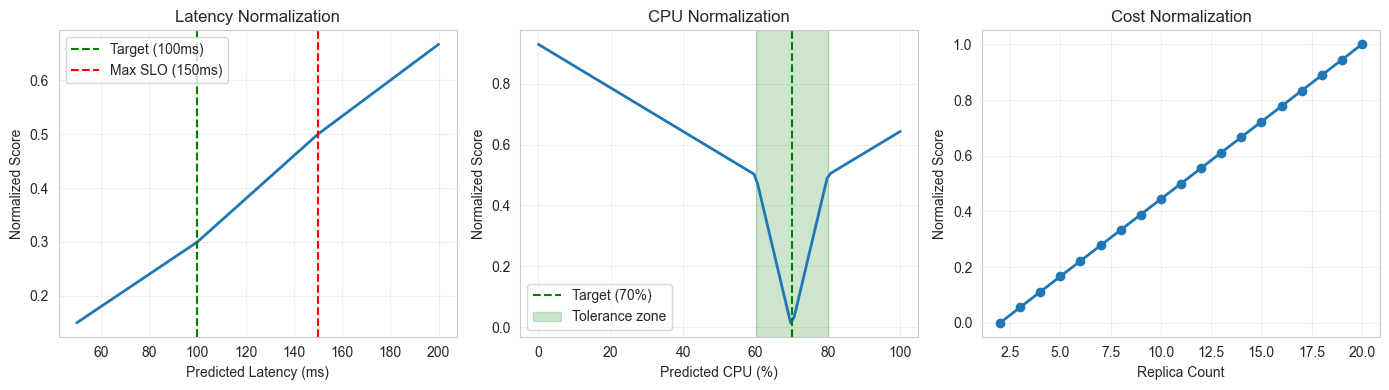

[OK] Normalization functions tested and plotted


In [5]:
# Test latency normalization
latencies = np.linspace(50, 200, 100)
latency_scores = [normalize_latency(lat, 100, 150) for lat in latencies]

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(latencies, latency_scores, linewidth=2)
plt.axvline(100, color='green', linestyle='--', label='Target (100ms)')
plt.axvline(150, color='red', linestyle='--', label='Max SLO (150ms)')
plt.xlabel('Predicted Latency (ms)')
plt.ylabel('Normalized Score')
plt.title('Latency Normalization')
plt.legend()
plt.grid(True, alpha=0.3)

# Test CPU normalization
cpu_values = np.linspace(0, 100, 100)
cpu_scores = [normalize_cpu(cpu, 70, 10) for cpu in cpu_values]

plt.subplot(1, 3, 2)
plt.plot(cpu_values, cpu_scores, linewidth=2)
plt.axvline(70, color='green', linestyle='--', label='Target (70%)')
plt.axvspan(60, 80, alpha=0.2, color='green', label='Tolerance zone')
plt.xlabel('Predicted CPU (%)')
plt.ylabel('Normalized Score')
plt.title('CPU Normalization')
plt.legend()
plt.grid(True, alpha=0.3)

# Test cost normalization
replicas = np.arange(2, 21)
cost_scores = [normalize_cost(r, 2, 20) for r in replicas]

plt.subplot(1, 3, 3)
plt.plot(replicas, cost_scores, linewidth=2, marker='o')
plt.xlabel('Replica Count')
plt.ylabel('Normalized Score')
plt.title('Cost Normalization')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/comparison_plots/normalization_functions.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Normalization functions tested and plotted")

## Step 6: Test Objective Function with Example Scenarios

In [6]:
# Define test scenarios
scenarios = [
    {
        'name': 'Perfect balance',
        'metrics': {'latency_p95': 95, 'cpu_usage': 70},
        'replicas': 5
    },
    {
        'name': 'High latency',
        'metrics': {'latency_p95': 180, 'cpu_usage': 85},
        'replicas': 3
    },
    {
        'name': 'Low CPU',
        'metrics': {'latency_p95': 70, 'cpu_usage': 30},
        'replicas': 10
    },
    {
        'name': 'Cost-efficient',
        'metrics': {'latency_p95': 110, 'cpu_usage': 75},
        'replicas': 3
    },
    {
        'name': 'Over-provisioned',
        'metrics': {'latency_p95': 60, 'cpu_usage': 40},
        'replicas': 15
    }
]

# Test with default weights
results = []
for scenario in scenarios:
    score, components = calculate_objective_score(
        predicted_metrics=scenario['metrics'],
        n_replicas=scenario['replicas'],
        weights=config['weights'],
        slo=config['slo'],
        constraints=config['constraints']
    )
    
    results.append({
        'Scenario': scenario['name'],
        'Replicas': scenario['replicas'],
        'Latency': scenario['metrics']['latency_p95'],
        'CPU': scenario['metrics']['cpu_usage'],
        'Total Score': f"{score:.3f}",
        'Latency Component': f"{components['latency_norm']:.3f}",
        'CPU Component': f"{components['cpu_norm']:.3f}",
        'Cost Component': f"{components['cost_norm']:.3f}"
    })

df_results = pd.DataFrame(results)
print("\n[RESULTS] Scenario Test Results:")
print(df_results.to_string(index=False))
print("\n[OK] All scenarios tested successfully")


[RESULTS] Scenario Test Results:
        Scenario  Replicas  Latency  CPU Total Score Latency Component CPU Component Cost Component
 Perfect balance         5       95   70       0.176             0.285         0.000          0.167
    High latency         3      180   85       0.472             0.600         0.536          0.056
         Low CPU        10       70   30       0.408             0.210         0.714          0.444
  Cost-efficient         3      110   75       0.256             0.340         0.250          0.056
Over-provisioned        15       60   40       0.427             0.180         0.643          0.722

[OK] All scenarios tested successfully


## Step 7: Visualize Score Landscape

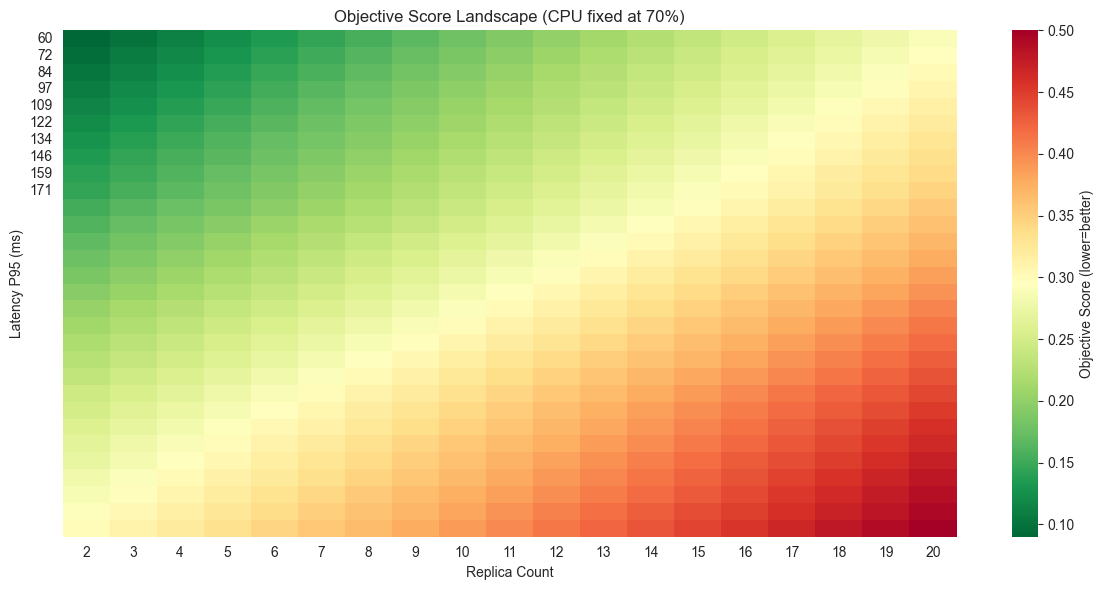

[OK] Score landscape visualized


In [7]:
# Create heatmap: latency vs replicas
latency_range = np.linspace(60, 180, 30)
replica_range = np.arange(2, 21)

score_matrix = np.zeros((len(latency_range), len(replica_range)))

for i, lat in enumerate(latency_range):
    for j, rep in enumerate(replica_range):
        metrics = {'latency_p95': lat, 'cpu_usage': 70}  # Fix CPU at target
        score, _ = calculate_objective_score(
            predicted_metrics=metrics,
            n_replicas=rep,
            weights=config['weights'],
            slo=config['slo'],
            constraints=config['constraints']
        )
        score_matrix[i, j] = score

plt.figure(figsize=(12, 6))
sns.heatmap(
    score_matrix,
    xticklabels=replica_range,
    yticklabels=[f"{int(lat)}" for lat in latency_range[::3]],
    cmap='RdYlGn_r',
    cbar_kws={'label': 'Objective Score (lower=better)'},
    annot=False
)
plt.xlabel('Replica Count')
plt.ylabel('Latency P95 (ms)')
plt.title('Objective Score Landscape (CPU fixed at 70%)')
plt.tight_layout()
plt.savefig('../results/comparison_plots/score_landscape.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Score landscape visualized")

## Step 8: Test Weight Sensitivity

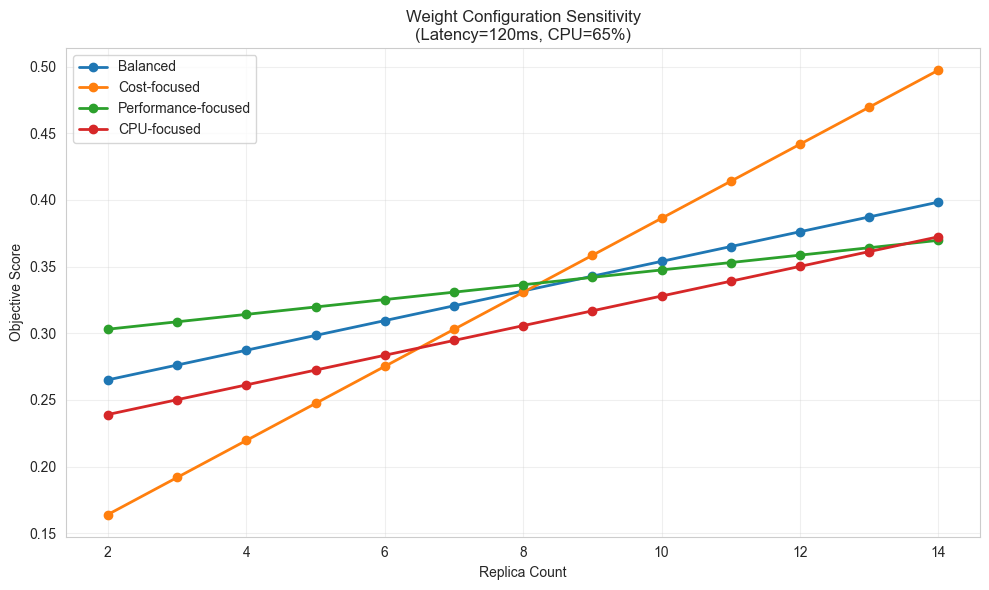

[OK] Weight sensitivity analyzed


In [8]:
# Test different weight configurations
weight_configs = [
    {'name': 'Balanced', 'latency': 0.5, 'cpu': 0.3, 'cost': 0.2},
    {'name': 'Cost-focused', 'latency': 0.3, 'cpu': 0.2, 'cost': 0.5},
    {'name': 'Performance-focused', 'latency': 0.6, 'cpu': 0.3, 'cost': 0.1},
    {'name': 'CPU-focused', 'latency': 0.3, 'cpu': 0.5, 'cost': 0.2}
]

# Test scenario
test_metrics = {'latency_p95': 120, 'cpu_usage': 65}
test_replicas = np.arange(2, 15)

plt.figure(figsize=(10, 6))

for wc in weight_configs:
    weights = {'latency': wc['latency'], 'cpu': wc['cpu'], 'cost': wc['cost']}
    scores = []
    
    for rep in test_replicas:
        score, _ = calculate_objective_score(
            predicted_metrics=test_metrics,
            n_replicas=rep,
            weights=weights,
            slo=config['slo'],
            constraints=config['constraints']
        )
        scores.append(score)
    
    plt.plot(test_replicas, scores, marker='o', label=wc['name'], linewidth=2)

plt.xlabel('Replica Count')
plt.ylabel('Objective Score')
plt.title('Weight Configuration Sensitivity\n(Latency=120ms, CPU=65%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/comparison_plots/weight_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print("[OK] Weight sensitivity analyzed")

## Step 9: Validate Score Range


[VALIDATION] Score Range Validation (1000 random tests):
  Min score: 0.1211
  Max score: 0.7338
  Mean score: 0.4554
  Std score: 0.1180

[OK] All scores in valid range [0, 1]


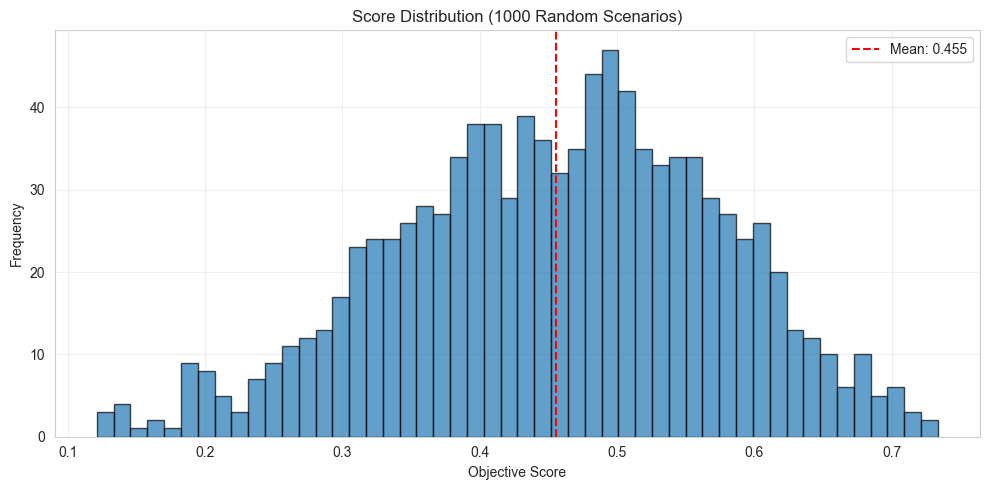

In [9]:
# Generate random scenarios to test score range
np.random.seed(42)
n_tests = 1000

all_scores = []
for _ in range(n_tests):
    latency = np.random.uniform(50, 200)
    cpu = np.random.uniform(20, 95)
    replicas = np.random.randint(2, 21)
    
    score, _ = calculate_objective_score(
        predicted_metrics={'latency_p95': latency, 'cpu_usage': cpu},
        n_replicas=replicas,
        weights=config['weights'],
        slo=config['slo'],
        constraints=config['constraints']
    )
    all_scores.append(score)

all_scores = np.array(all_scores)

print(f"\n[VALIDATION] Score Range Validation ({n_tests} random tests):")
print(f"  Min score: {all_scores.min():.4f}")
print(f"  Max score: {all_scores.max():.4f}")
print(f"  Mean score: {all_scores.mean():.4f}")
print(f"  Std score: {all_scores.std():.4f}")

if 0 <= all_scores.min() and all_scores.max() <= 1:
    print("\n[OK] All scores in valid range [0, 1]")
else:
    print(f"\n[ERROR] Invalid scores detected!")

# Plot distribution
plt.figure(figsize=(10, 5))
plt.hist(all_scores, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Objective Score')
plt.ylabel('Frequency')
plt.title(f'Score Distribution ({n_tests} Random Scenarios)')
plt.axvline(all_scores.mean(), color='red', linestyle='--', label=f'Mean: {all_scores.mean():.3f}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/comparison_plots/score_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary & Next Steps

### Completed
- Implemented normalization functions for latency, CPU, and cost
- Created multi-objective scoring function
- Tested with realistic scenarios
- Visualized score landscapes and weight sensitivity
- Validated score range [0, 1]

### Key Findings
- Latency normalization has non-linear SLO-aware penalty
- CPU normalization favors target utilization (70%)
- Cost increases linearly with replica count
- Weight configuration significantly affects optimal decisions

### Next Steps
1. Move to `2_decision_algorithm.ipynb` to implement full decision logic
2. Integrate Linear Regression model for metric prediction
3. Add safety constraints (cooldown, oscillation detection)
4. Test end-to-end decision flow